In [1]:
# load data
import pandas as pd 

df = pd.read_csv('data.csv')
df.head()

,study_hours,attendance,sleep_hours,previous_score,assignment_score,internet_usage,parent_education,stress_level,part_time_job,health_score,lulus
0,6.993428,75.762403,5.982258,83.532909,85.443432,5.341747,4,4.526274,0,76.837222,1
1,5.723471,75.465859,6.541751,78.290798,77.174064,5.024511,2,7.937294,0,61.079328,0
2,7.295377,62.043568,6.103928,87.119834,74.407064,4.137690,4,3.189430,1,77.160849,0
3,9.046060,76.699098,7.165627,100.000000,100.000000,4.994947,4,1.000000,1,43.647852,1
4,5.531693,87.328291,8.795768,70.186293,58.289333,5.981683,3,8.000514,0,50.719143,0


In [2]:
# info data 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   study_hours       5000 non-null   float64
 1   attendance        5000 non-null   float64
 2   sleep_hours       5000 non-null   float64
 3   previous_score    5000 non-null   float64
 4   assignment_score  5000 non-null   float64
 5   internet_usage    5000 non-null   float64
 6   parent_education  5000 non-null   int64  
 7   stress_level      5000 non-null   float64
 8   part_time_job     5000 non-null   int64  
 9   health_score      5000 non-null   float64
 10  lulus             5000 non-null   int64  
dtypes: float64(8), int64(3)
memory usage: 429.8 KB


In [3]:
# describe data 
df.describe()

,study_hours,attendance,sleep_hours,previous_score,assignment_score,internet_usage,parent_education,stress_level,part_time_job,health_score,lulus
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,6.010297,79.816254,7.004749,79.716236,75.480107,4.998262,2.479600,4.976367,0.499000,70.211672,0.551400
std,1.988367,9.863153,1.459560,13.205398,14.842678,1.952719,1.117781,1.984125,0.500049,14.747325,0.497401
min,0.000000,50.000000,3.000000,24.917214,16.810420,1.000000,1.000000,1.000000,0.000000,30.000000,0.000000
25%,4.684190,73.134171,6.008670,70.476232,65.724668,3.601549,1.000000,3.536461,0.000000,59.995936,0.000000
50%,6.026931,79.825495,7.014876,80.191797,75.871514,4.997914,2.000000,4.955063,0.000000,70.378929,1.000000
75%,7.332021,86.772381,8.013301,89.940494,86.555635,6.354883,3.000000,6.344204,1.000000,80.741291,1.000000
max,12.000000,100.000000,10.000000,100.000000,100.000000,10.000000,4.000000,10.000000,1.000000,100.000000,1.000000


In [4]:
# cek missing value 
df.isnull().sum()


study_hours         0
attendance          0
sleep_hours         0
previous_score      0
assignment_score    0
internet_usage      0
parent_education    0
stress_level        0
part_time_job       0
health_score        0
lulus               0
dtype: int64

In [5]:
df['attendance'].max()

np.float64(100.0)

In [6]:
# cek data duplikat 
print(f"jumlah data duplikat: {df.duplicated().sum()}")
print("-"*40)
duplicate_rows = df[df.duplicated()]
display(duplicate_rows)

jumlah data duplikat: 0
----------------------------------------


,study_hours,attendance,sleep_hours,previous_score,assignment_score,internet_usage,parent_education,stress_level,part_time_job,health_score,lulus


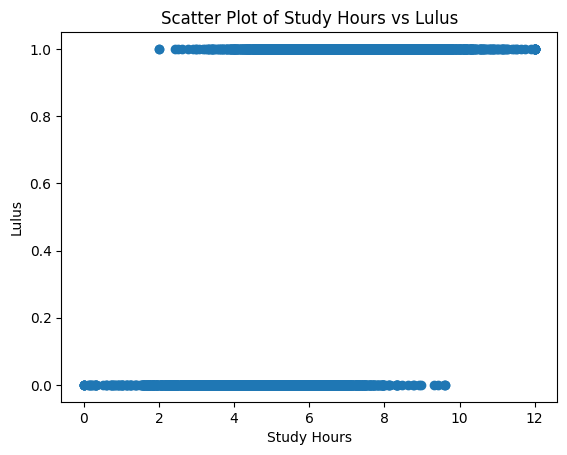

In [7]:
# visualsisasi 
import seaborn as sns
# visualisasi scatter plot 
import matplotlib.pyplot as plt

plt.scatter(df['study_hours'], df['lulus'])
plt.xlabel('Study Hours')
plt.ylabel('Lulus')
plt.title('Scatter Plot of Study Hours vs Lulus')
plt.show()

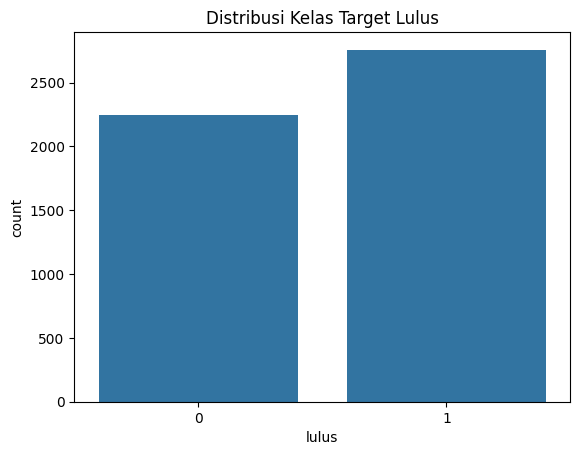

In [8]:
# liat distribusi kelas target 
sns.countplot(x='lulus', data=df)
plt.title('Distribusi Kelas Target Lulus')
plt.show()

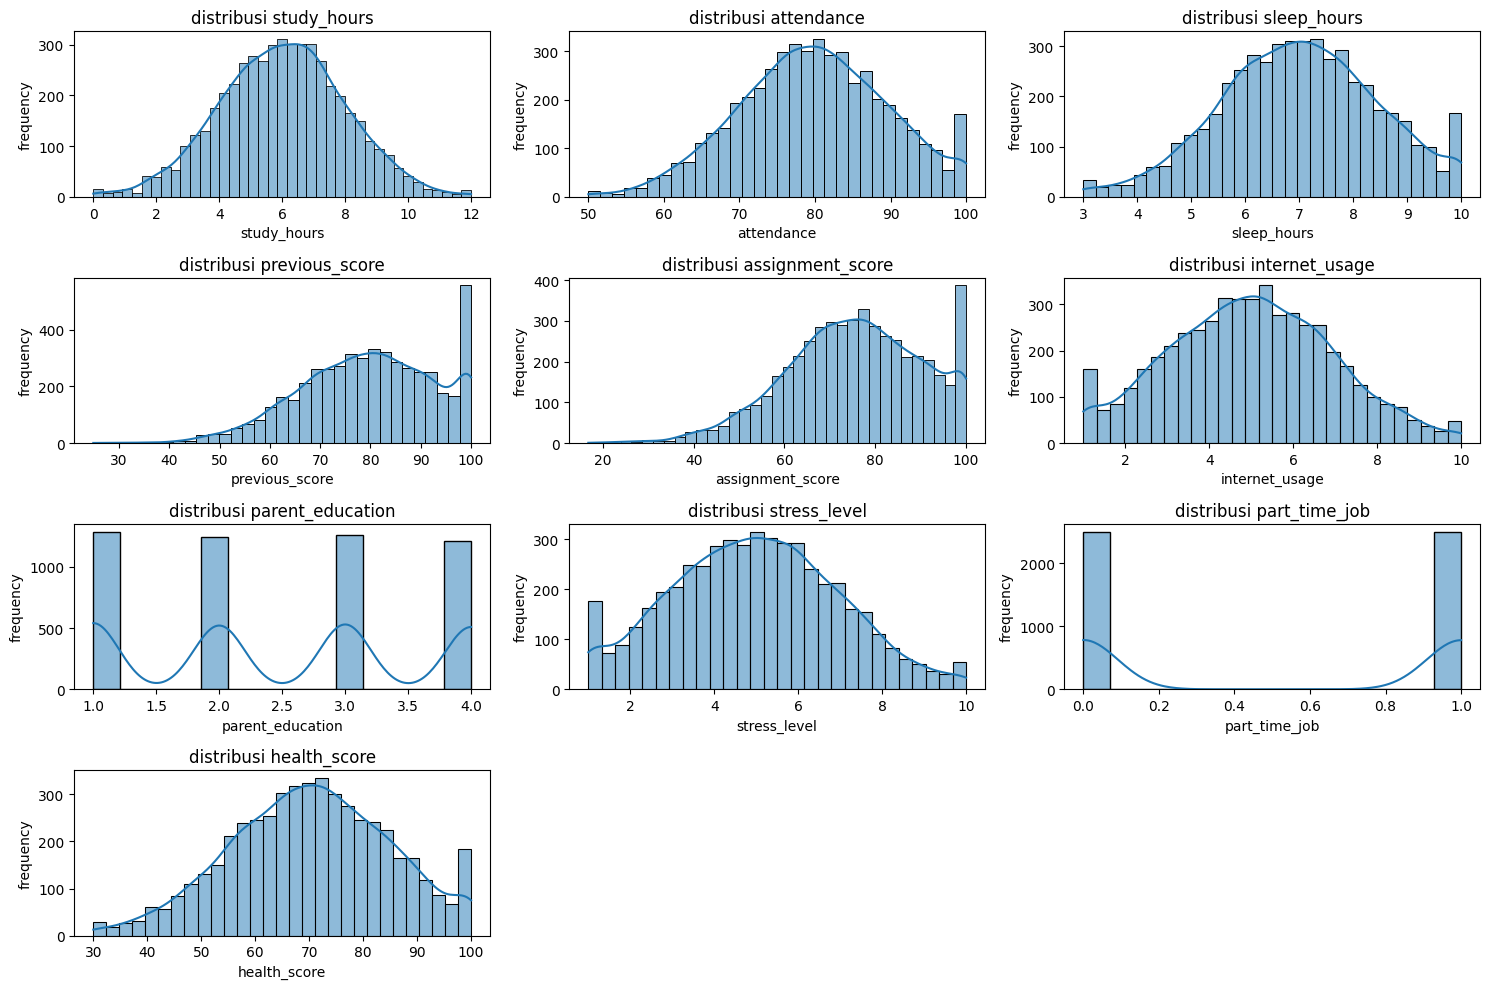

In [9]:
# distribusi data 
plt.figure(figsize=(15,10))
for i,col in enumerate(df.drop(columns=['lulus']).columns):
    plt.subplot(4,3,i+1)
    sns.histplot(data=df,x=col,kde=True)
    plt.title(f'distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('frequency')
plt.tight_layout()
plt.show()

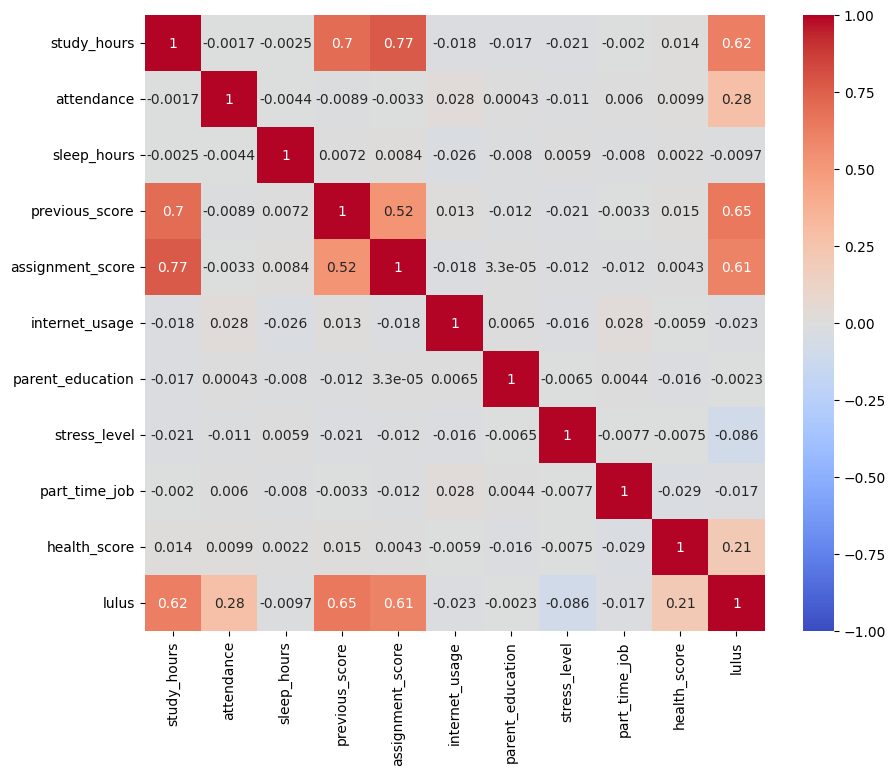

In [10]:
# heatmap kerelasi 
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),vmin=-1,center=0,vmax=1 ,annot=True, cmap='coolwarm')
plt.show()

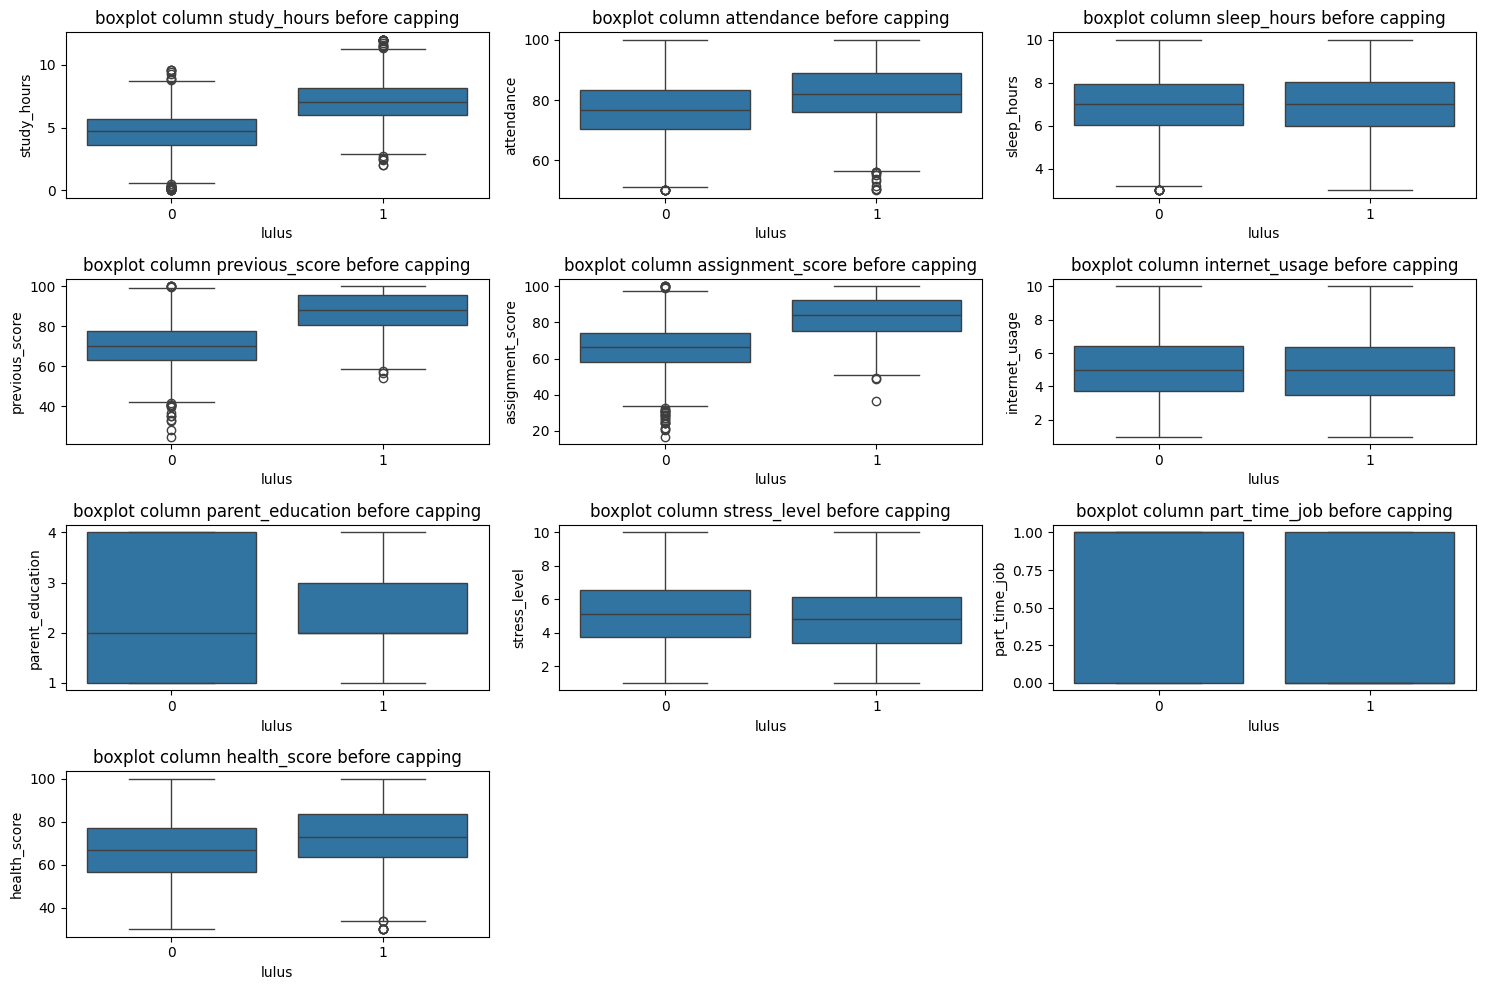

In [11]:
# boxplot untuk mengidentifikasi outlier 
plt.figure(figsize=(15,10))
for i,col in enumerate(df.drop(columns=['lulus']).columns):
    plt.subplot(4,3,i+1)
    sns.boxplot(data=df,x='lulus',y=col)
    plt.title(f"boxplot column {col} before capping")
plt.tight_layout()
plt.show()

In [12]:
# feature engineering 

# buat fitur ratio antara study dan sleep hours 
df['study_sleep_ratio'] = df['study_hours'] / (df['sleep_hours'] + 1e-5)  # tambahkan epsilon untuk menghindari pembagian dengan nol

# buat fitur interaksi antara attendance dan study hours
df['attendance_study_interaction'] = df['attendance'] * df['study_hours']

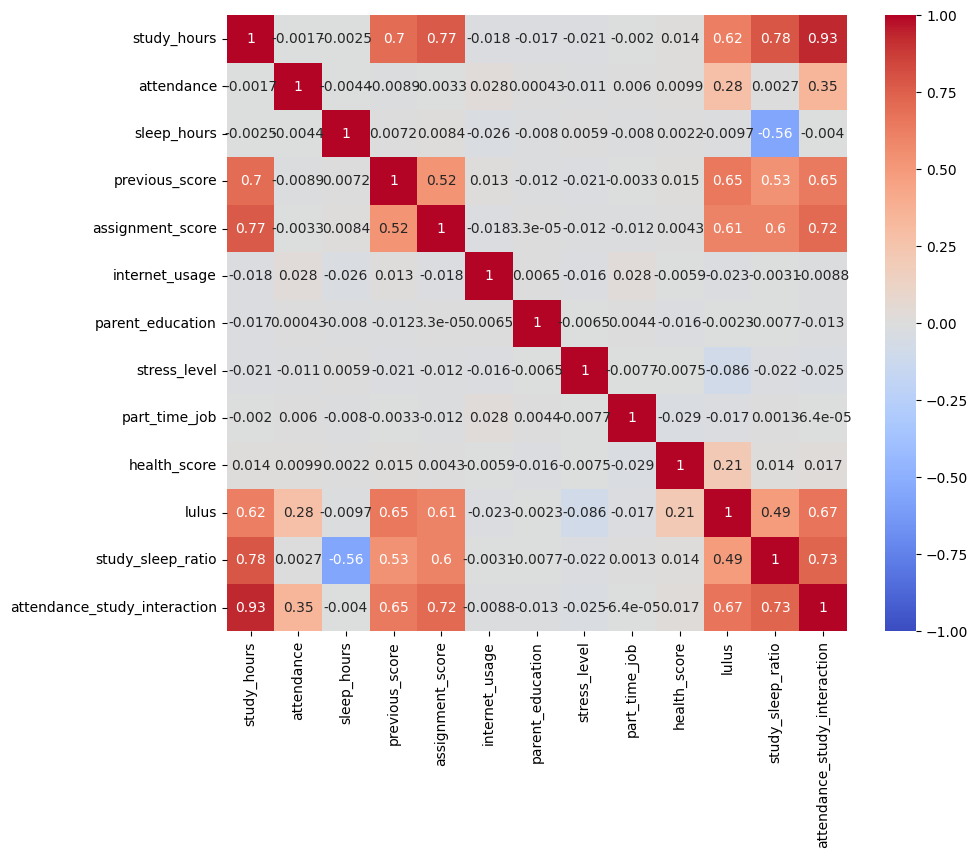

In [26]:
# heatmap korelasi setelah feature engineering
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),vmin=-1,center=0,vmax=1 ,annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# feature selection
# data_selected = df[['study_hours', 'sleep_hours']]copy() 

In [ ]:
# split data 
from sklearn.model_selection import train_test_split

X = df.drop(columns=['lulus'])
y = df['lulus']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.head()


,study_hours,attendance,sleep_hours,previous_score,assignment_score,internet_usage,parent_education,stress_level,part_time_job,health_score,study_sleep_ratio,attendance_study_interaction
4227,6.839411,73.729514,6.649181,73.259372,65.148964,1.719569,4,7.919778,0,58.436355,1.028608,504.266464
4676,7.385538,69.736464,6.391619,70.086753,78.138365,4.245161,1,7.019430,0,78.449304,1.155502,515.041308
800,7.876568,82.952326,6.148288,74.620533,74.688875,5.014434,3,4.904494,0,72.846494,1.281097,653.379602
3671,7.744631,95.696286,7.111610,95.088574,73.162096,3.999784,3,3.383007,1,82.627635,1.089011,741.132399
4193,1.147216,83.465270,8.677253,59.786375,53.102818,3.365593,2,3.797776,0,85.077507,0.132209,95.752682


In [21]:
# train model 
from sklearn import pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV


# Pipeline random forest
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

param_rf = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 5, 10],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4]
}

In [22]:
# pipeline logistic regression
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42))
])

param_lr = {
    'lr__C': [0.01, 0.1, 1, 10]
}

In [23]:
# random search cv untuk random forest
search_rf = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_rf,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    verbose=1,
    n_jobs=-1
)

search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'rf__max_depth': [None, 5, ...], 'rf__min_samples_leaf': [1, 2, ...], 'rf__min_samples_split': [2, 5, ...], 'rf__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that ca

In [24]:
# random search cv untuk logistic regression
search_lr = RandomizedSearchCV(
    estimator=pipeline_lr,
    param_distributions=param_lr,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    verbose=1,
    n_jobs=-1
)

search_lr.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


c:\ml-mle-students5k-rows\venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'lr__C': [0.01, 0.1, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbo

In [25]:
# bandingkan model terbaik
print("Best Random Forest Score:", search_rf.best_score_)
print("Best Logistic Regression Score:", search_lr.best_score_)

Best Random Forest Score: 0.9317499999999999
Best Logistic Regression Score: 0.9975000000000002


In [49]:
best_model = search_rf if search_rf.best_score_ > search_lr.best_score_ else search_lr
print("Best Model:", "Random Forest" if best_model == search_rf else "Logistic Regression")

Best Model: Logistic Regression


In [50]:
# evaluasi model 
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay

y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       443
           1       0.99      0.99      0.99       557

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



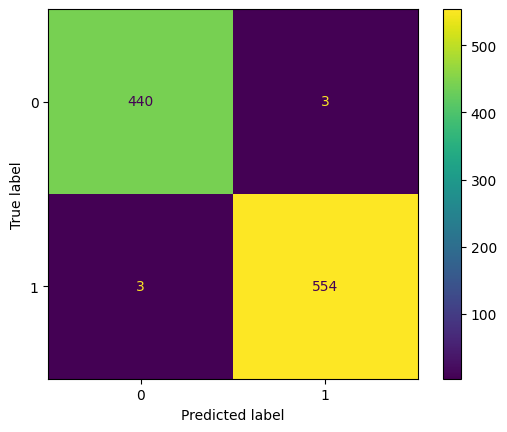

In [51]:
# confusion matrix 

confusion_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=best_model.classes_)
disp.plot()
plt.show()

In [52]:
# feature importance random
model = search_rf.best_estimator_.named_steps['rf']
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importance)

                         feature  importance
3                 previous_score    0.220618
11  attendance_study_interaction    0.218638
4               assignment_score    0.151162
0                    study_hours    0.126913
9                   health_score    0.076838
1                     attendance    0.075902
10             study_sleep_ratio    0.059541
7                   stress_level    0.024644
5                 internet_usage    0.019325
2                    sleep_hours    0.018647
6               parent_education    0.005685
8                  part_time_job    0.002087


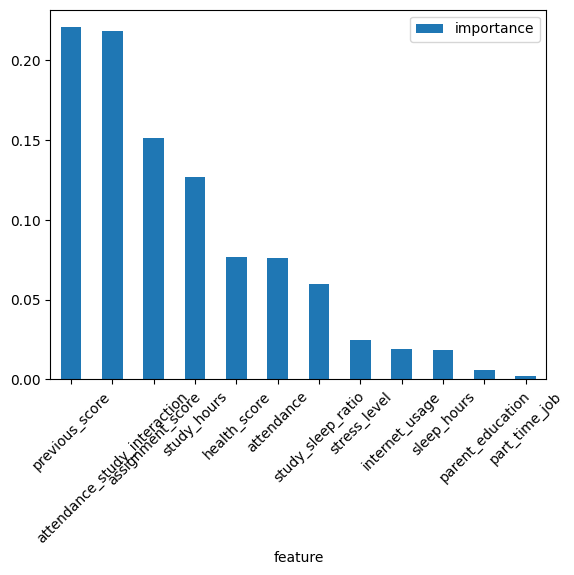

In [53]:
# visualisasi feature importance 
import matplotlib.pyplot as plt

feature_importance.plot(
    x='feature',
    y='importance',
    kind='bar'
)

plt.xticks(rotation=45)
plt.show()

In [54]:
print("Train score:", best_model.score(X_train, y_train))
print("Test score :", best_model.score(X_test, y_test))

Train score: 0.9985
Test score : 0.994


In [2]:
import sklearn
print(sklearn.__version__)

1.8.0


In [55]:
# simpan model 
import joblib

joblib.dump(best_model, 'model.joblib')

['model.joblib']

NameError: name 'X_test' is not defined